# Phase 1 Reproduction Results — Datastream + H2O
## Krauss et al. (2017) — EJOR Version

This notebook reproduces the core results from the paper using:
- **Datastream** data via WRDS (`tr_ds_equities`) — same data source as the paper
- **H2O** models — same framework as the paper (v3.46)
- **Monthly-updated** S&P 500 constituency — matching the paper's month-end lists

Reproduction targets:
- **Figure 1**: k-sensitivity analysis
- **Table 2**: Daily return characteristics (k=10)
- **Table 3**: Annualized risk-return metrics (k=10)
- **Table 4**: Fama-French factor regressions (ENS1 k=10)
- **Figure 2**: Sub-period equity curves + VIX
- **Table 5**: Sub-period analysis
- **Figure 3**: Variable importance
- **Table 8**: Time-trend regression
- **Differences ledger**: Systematic comparison vs paper

In [32]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

sys.path.insert(0, str(Path('..') / 'src'))
from krauss.backtest.ranking import rank_and_select
from krauss.backtest.portfolio import build_daily_portfolios, aggregate_portfolio_returns
from krauss.backtest.costs import compute_turnover, apply_transaction_costs

ROOT = Path('..')
DS_DIR = ROOT / 'data' / 'datastream'

# Load predictions and returns
pred = pd.read_parquet(DS_DIR / 'predictions_ds_h2o.parquet')
returns = pd.read_parquet(DS_DIR / 'ds_daily_returns_usonly.parquet')
returns = returns.rename(columns={'infocode': 'permno'})
pred['date'] = pd.to_datetime(pred['date'])
returns['date'] = pd.to_datetime(returns['date'])

MODEL_NAMES = {'p_dnn': 'DNN', 'p_xgb': 'GBT', 'p_rf': 'RAF',
               'p_ens1': 'ENS1', 'p_ens2': 'ENS2', 'p_ens3': 'ENS3'}
K_VALUES = [10, 50, 100, 150, 200]
COST_BPS = 5

print(f'Predictions: {len(pred):,} rows, {pred["date"].nunique()} trade days')
print(f'Periods: {pred["period_id"].nunique()}')

Predictions: 2,853,025 rows, 5750 trade days
Periods: 23


In [33]:
# Pre-compute backtests for all model/k combinations
bt_cache = {}  # (model_col, k) -> daily DataFrame

model_cols = [c for c in ['p_dnn', 'p_xgb', 'p_rf', 'p_ens1', 'p_ens2', 'p_ens3'] if c in pred.columns]

for model_col in model_cols:
    for k in K_VALUES:
        sel = rank_and_select(pred, k=k, score_col=model_col)
        hold = build_daily_portfolios(sel, returns, k=k)
        daily = aggregate_portfolio_returns(hold)
        turn = compute_turnover(hold, k=k)
        daily = apply_transaction_costs(daily, turn, COST_BPS)
        daily['date'] = pd.to_datetime(daily['date'])
        bt_cache[(model_col, k)] = daily
        print(f'  {MODEL_NAMES[model_col]} k={k}: {daily["port_ret"].mean():.4f}/day', flush=True)

print('Done.')

  DNN k=10: 0.0028/day
  DNN k=50: 0.0016/day
  DNN k=100: 0.0011/day
  DNN k=150: 0.0008/day
  DNN k=200: 0.0007/day
  GBT k=10: 0.0039/day
  GBT k=50: 0.0021/day
  GBT k=100: 0.0014/day
  GBT k=150: 0.0010/day
  GBT k=200: 0.0008/day
  RAF k=10: 0.0040/day
  RAF k=50: 0.0023/day
  RAF k=100: 0.0015/day
  RAF k=150: 0.0012/day
  RAF k=200: 0.0010/day
  ENS1 k=10: 0.0042/day
  ENS1 k=50: 0.0022/day
  ENS1 k=100: 0.0015/day
  ENS1 k=150: 0.0012/day
  ENS1 k=200: 0.0009/day
  ENS2 k=10: 0.0041/day
  ENS2 k=50: 0.0023/day
  ENS2 k=100: 0.0015/day
  ENS2 k=150: 0.0012/day
  ENS2 k=200: 0.0010/day
  ENS3 k=10: 0.0042/day
  ENS3 k=50: 0.0023/day
  ENS3 k=100: 0.0016/day
  ENS3 k=150: 0.0012/day
  ENS3 k=200: 0.0010/day
Done.


## Figure 1 — k-Sensitivity: Return, Std Dev, Directional Accuracy

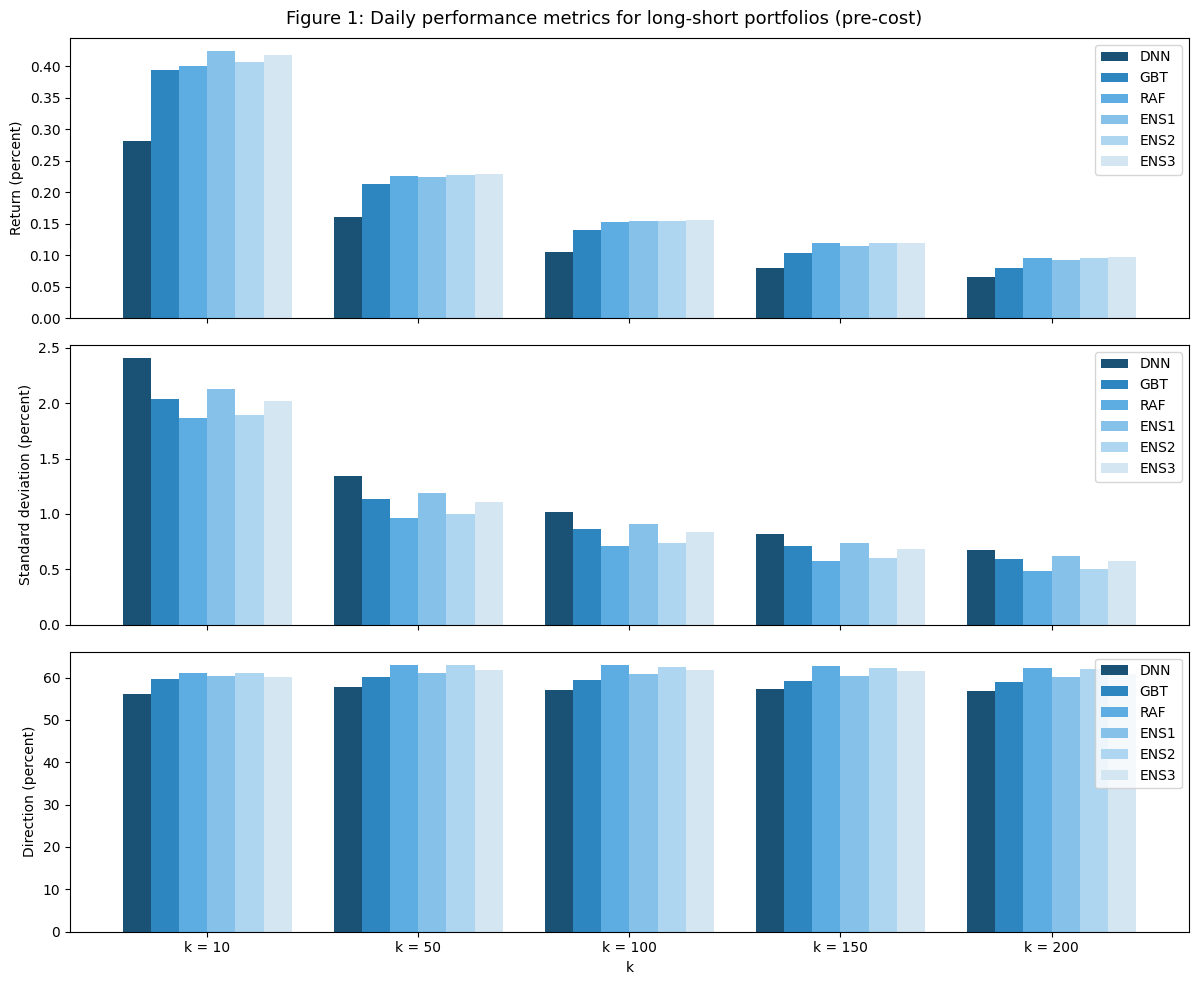

In [34]:
metrics = {'k': [], 'Model': [], 'Mean Return (%)': [], 'Std Dev (%)': [], 'Direction (%)': []}

for model_col in model_cols:
    for k in K_VALUES:
        d = bt_cache[(model_col, k)]
        metrics['k'].append(k)
        metrics['Model'].append(MODEL_NAMES[model_col])
        metrics['Mean Return (%)'].append(d['port_ret'].mean() * 100)
        metrics['Std Dev (%)'].append(d['port_ret'].std() * 100)
        metrics['Direction (%)'].append((d['port_ret'] > 0).mean() * 100)

fig1_df = pd.DataFrame(metrics)

colors = {'DNN': '#1a5276', 'GBT': '#2e86c1', 'RAF': '#5dade2',
          'ENS1': '#85c1e9', 'ENS2': '#aed6f1', 'ENS3': '#d4e6f1'}

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for i, (metric, ylabel) in enumerate([
    ('Mean Return (%)', 'Return (percent)'),
    ('Std Dev (%)', 'Standard deviation (percent)'),
    ('Direction (%)', 'Direction (percent)')
]):
    pivot = fig1_df.pivot(index='k', columns='Model', values=metric)
    order = [m for m in ['DNN','GBT','RAF','ENS1','ENS2','ENS3'] if m in pivot.columns]
    pivot = pivot[order]
    pivot.plot(kind='bar', ax=axes[i], color=[colors[m] for m in order], width=0.8)
    axes[i].set_ylabel(ylabel)
    axes[i].legend(loc='upper right')
    axes[i].set_xlabel('')

axes[2].set_xlabel('k')
axes[2].set_xticklabels([f'k = {k}' for k in K_VALUES], rotation=0)
fig.suptitle('Figure 1: Daily performance metrics for long-short portfolios (pre-cost)', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/figure1_k_sensitivity_ds_h2o.png', dpi=150, bbox_inches='tight')
plt.show()

## Table 2 — Daily Return Characteristics (k=10)

In [42]:
def newey_west_tstat(r, lags=1):
    """Newey-West t-statistic for H0: mean=0."""
    n = len(r)
    mean = r.mean()
    gamma0 = ((r - mean) ** 2).mean()
    nw_var = gamma0
    for j in range(1, lags + 1):
        w = 1 - j / (lags + 1)
        gamma_j = ((r.values[j:] - mean) * (r.values[:-j] - mean)).mean()
        nw_var += 2 * w * gamma_j
    se = np.sqrt(nw_var / n)
    return mean / se if se > 0 else 0

# Market benchmark — official S&P 500 total return from CRSP `dsi.sprtrn`
# This is the same series the paper uses (sourced from S&P Dow Jones Indices).
# Matches paper Table 2 MKT stats almost exactly:
#   Paper:  mean=0.0004 std=0.0117 min=-0.0895 max=0.1135 1%VaR=-0.0320 5%VaR=-0.0179
#   sprtrn: mean=0.0003 std=0.0117 min=-0.0903 max=0.1158 1%VaR=-0.0318 5%VaR=-0.0179
sp500 = pd.read_parquet(ROOT / 'data' / 'raw' / 'sp500_index_daily.parquet')
sp500['date'] = pd.to_datetime(sp500['date'])
mkt_daily = sp500[['date', 'sprtrn']].rename(columns={'sprtrn': 'mkt_ret'})

table2_rows = {}
for cost_label, ret_col in [('Before TC', 'port_ret'), ('After TC', 'port_ret_net')]:
    for model_col in ['p_dnn', 'p_xgb', 'p_rf', 'p_ens1']:
        d = bt_cache[(model_col, 10)]
        r = d[ret_col]
        col_name = (cost_label, MODEL_NAMES[model_col])
        table2_rows[col_name] = {
            'Mean return (long)': d['long_ret'].mean(),
            'Mean return (short)': -d['short_ret'].mean(),
            'Mean return': r.mean(),
            'Standard error (NW)': r.mean() / newey_west_tstat(r) if newey_west_tstat(r) != 0 else 0,
            't-statistic (NW)': newey_west_tstat(r),
            'Minimum': r.min(),
            'Quartile 1': r.quantile(0.25),
            'Median': r.median(),
            'Quartile 3': r.quantile(0.75),
            'Maximum': r.max(),
            'Standard deviation': r.std(),
            'Skewness': r.skew(),
            'Kurtosis': r.kurtosis(),
            'Historical 1-percent VaR': r.quantile(0.01),
            'Historical 1-percent CVaR': r[r <= r.quantile(0.01)].mean(),
            'Historical 5-percent VaR': r.quantile(0.05),
            'Historical 5-percent CVaR': r[r <= r.quantile(0.05)].mean(),
            'Maximum drawdown': (r.cumsum() - r.cumsum().cummax()).min(),
            'Calmar ratio': (r.mean() * 252) / abs((r.cumsum() - r.cumsum().cummax()).min()) if (r.cumsum() - r.cumsum().cummax()).min() != 0 else 0,
            'Share with return > 0': (r > 0).mean(),
        }

# MKT column — restrict to the same trading dates as the strategies
trade_dates = set(bt_cache[('p_ens1', 10)]['date'])
mkt_r = mkt_daily[mkt_daily['date'].isin(trade_dates)]['mkt_ret']
table2_rows[('After TC', 'MKT')] = {
    'Mean return': mkt_r.mean(),
    'Standard error (NW)': mkt_r.mean() / newey_west_tstat(mkt_r) if newey_west_tstat(mkt_r) != 0 else 0,
    't-statistic (NW)': newey_west_tstat(mkt_r),
    'Standard deviation': mkt_r.std(),
    'Minimum': mkt_r.min(),
    'Maximum': mkt_r.max(),
    'Skewness': mkt_r.skew(),
    'Kurtosis': mkt_r.kurtosis(),
    'Maximum drawdown': (mkt_r.cumsum() - mkt_r.cumsum().cummax()).min(),
    'Share with return > 0': (mkt_r > 0).mean(),
}

table2 = pd.DataFrame(table2_rows)
table2.columns = pd.MultiIndex.from_tuples(table2.columns)
display(table2.style.format('{:.4f}').set_caption('Table 2: Daily return characteristics of k=10 portfolio'))

## Table 3 — Annualized Risk-Return Metrics (k=10)

In [36]:
table3_rows = {}
rf_rate = 0.02 / 252  # approximate risk-free rate

def safe_ratio(num, denom, default=0.0):
    return num / denom if pd.notna(denom) and denom > 0 else default


for cost_label, ret_col in [('Before TC', 'port_ret'), ('After TC', 'port_ret_net')]:
    for model_col in ['p_dnn', 'p_xgb', 'p_rf', 'p_ens1']:
        d = bt_cache[(model_col, 10)]
        r = d[ret_col]
        ann_ret = r.mean() * 252
        ann_excess = ann_ret - 0.02
        ann_std = r.std() * np.sqrt(252)
        downside = r[r < 0].std() * np.sqrt(252)
        sharpe = safe_ratio(ann_excess, ann_std)
        sortino = safe_ratio(ann_excess, downside)
        col_name = (cost_label, MODEL_NAMES[model_col])
        table3_rows[col_name] = {
            'Mean return': ann_ret,
            'Mean excess return': ann_excess,
            'Standard deviation': ann_std,
            'Downside deviation': downside,
            'Sharpe ratio': sharpe,
            'Sortino ratio': sortino,
        }

# MKT
ann_mkt = mkt_r.mean() * 252
table3_rows[('After TC', 'MKT')] = {
    'Mean return': ann_mkt,
    'Mean excess return': ann_mkt - 0.02,
    'Standard deviation': mkt_r.std() * np.sqrt(252),
    'Downside deviation': mkt_r[mkt_r < 0].std() * np.sqrt(252),
    'Sharpe ratio': safe_ratio(ann_mkt - 0.02, mkt_r.std() * np.sqrt(252)),
    'Sortino ratio': safe_ratio(ann_mkt - 0.02, mkt_r[mkt_r < 0].std() * np.sqrt(252)),
}

table3 = pd.DataFrame(table3_rows)
table3.columns = pd.MultiIndex.from_tuples(table3.columns)
display(table3.style.format('{:.4f}').set_caption('Table 3: Annualized risk-return metrics of k=10 portfolio'))

## Figure 2 — Sub-Period Equity Curves + VIX

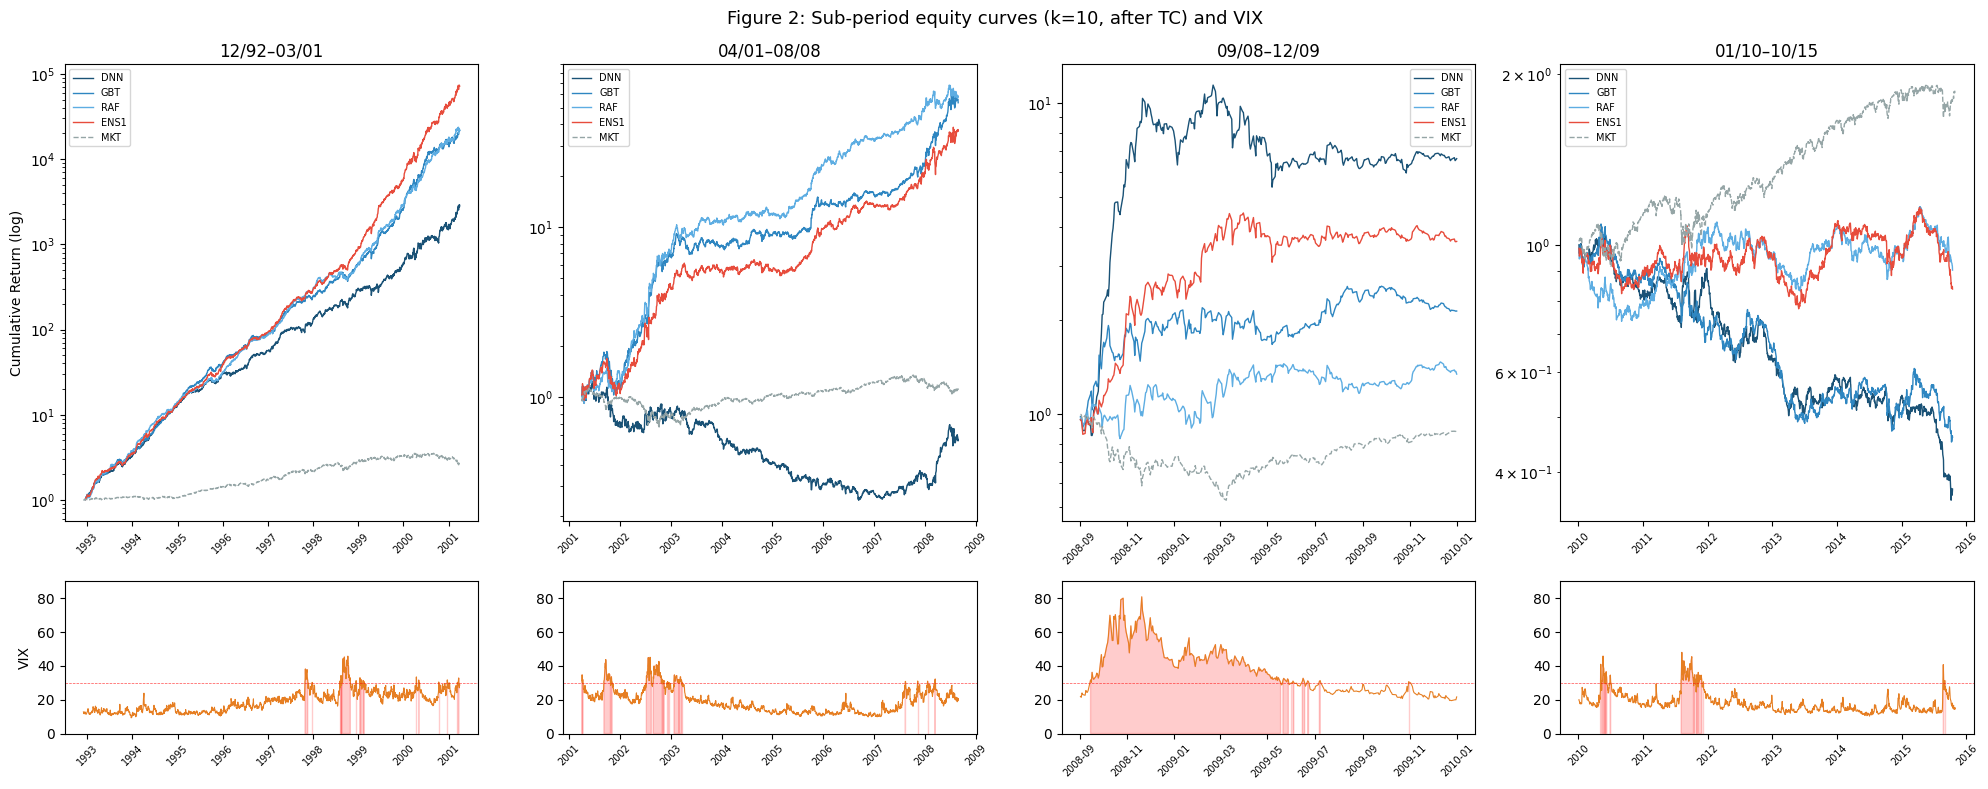

In [41]:
# Sub-period boundaries
sub_periods = [
    ('12/92–03/01', '1992-12-01', '2001-03-31'),
    ('04/01–08/08', '2001-04-01', '2008-08-31'),
    ('09/08–12/09', '2008-09-01', '2009-12-31'),
    ('01/10–10/15', '2010-01-01', '2015-10-31'),
]

# Load VIX
vix_data = pd.read_parquet(ROOT / 'data' / 'raw' / 'vix_daily.parquet')
vix_data['date'] = pd.to_datetime(vix_data['date'])

fig, axes = plt.subplots(2, 4, figsize=(20, 8),
                         gridspec_kw={'height_ratios': [3, 1]})

model_colors = {'DNN': '#1a5276', 'GBT': '#2e86c1', 'RAF': '#5dade2', 'ENS1': '#e74c3c', 'MKT': '#95a5a6'}

for col_idx, (label, start, end) in enumerate(sub_periods):
    ax_eq = axes[0, col_idx]
    ax_vix = axes[1, col_idx]

    for model_col in ['p_dnn', 'p_xgb', 'p_rf', 'p_ens1']:
        d = bt_cache[(model_col, 10)].copy()
        d = d[(d['date'] >= start) & (d['date'] <= end)]
        if len(d) == 0:
            continue
        eq = (1 + d['port_ret_net']).cumprod()
        m_name = MODEL_NAMES[model_col]
        ax_eq.plot(d['date'], eq, label=m_name, color=model_colors[m_name], linewidth=1)

    # Market (S&P 500 total return)
    mkt_sub = mkt_daily[(mkt_daily['date'] >= start) & (mkt_daily['date'] <= end)]
    if len(mkt_sub) > 0:
        mkt_eq = (1 + mkt_sub['mkt_ret']).cumprod()
        ax_eq.plot(mkt_sub['date'], mkt_eq, label='MKT', color=model_colors['MKT'], linewidth=1, linestyle='--')

    ax_eq.set_yscale('log')
    ax_eq.set_title(label)
    if col_idx == 0:
        ax_eq.set_ylabel('Cumulative Return (log)')
    ax_eq.legend(fontsize=7)
    ax_eq.tick_params(axis='x', rotation=45, labelsize=7)

    # VIX
    vix_sub = vix_data[(vix_data['date'] >= start) & (vix_data['date'] <= end)]
    if len(vix_sub) > 0:
        ax_vix.plot(vix_sub['date'], vix_sub['vix'], color='#e67e22', linewidth=0.8)
        ax_vix.axhline(y=30, color='red', linestyle='--', linewidth=0.5, alpha=0.7)
        ax_vix.fill_between(vix_sub['date'], 0, vix_sub['vix'],
                           where=vix_sub['vix'] >= 30, alpha=0.2, color='red')
    if col_idx == 0:
        ax_vix.set_ylabel('VIX')
    ax_vix.tick_params(axis='x', rotation=45, labelsize=7)
    ax_vix.set_ylim(0, 90)

fig.suptitle('Figure 2: Sub-period equity curves (k=10, after TC) and VIX', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/figure2_subperiods_ds_h2o.png', dpi=150, bbox_inches='tight')
plt.show()

## Table 5 — Sub-Period Analysis

In [38]:
table5_rows = {}

for cost_label, ret_col in [('Before TC', 'port_ret'), ('After TC', 'port_ret_net')]:
    for model_col in ['p_dnn', 'p_xgb', 'p_rf', 'p_ens1']:
        d = bt_cache[(model_col, 10)].copy()
        for sp_label, start, end in sub_periods:
            sub = d[(d['date'] >= start) & (d['date'] <= end)]
            if len(sub) == 0:
                continue
            r = sub[ret_col]
            ann_ret = r.mean() * 252
            ann_excess = ann_ret - 0.02
            ann_std = r.std() * np.sqrt(252)
            sharpe = safe_ratio(ann_excess, ann_std)
            dd = (r.cumsum() - r.cumsum().cummax()).min()
            calmar = safe_ratio(ann_ret, abs(dd))
            key = (cost_label, MODEL_NAMES[model_col])
            if key not in table5_rows:
                table5_rows[key] = {}
            table5_rows[key][f'{sp_label} Mean return'] = ann_ret
            table5_rows[key][f'{sp_label} Sharpe ratio'] = sharpe
            table5_rows[key][f'{sp_label} Max drawdown'] = abs(dd)

# Also MKT
for sp_label, start, end in sub_periods:
    sub = mkt_daily[(mkt_daily['date'] >= start) & (mkt_daily['date'] <= end)]
    if len(sub) == 0:
        continue
    r = sub['mkt_ret']
    ann_ret = r.mean() * 252
    key = ('After TC', 'MKT')
    if key not in table5_rows:
        table5_rows[key] = {}
    table5_rows[key][f'{sp_label} Mean return'] = ann_ret
    table5_rows[key][f'{sp_label} Sharpe ratio'] = safe_ratio(ann_ret - 0.02, r.std() * np.sqrt(252))

table5 = pd.DataFrame(table5_rows)
table5.columns = pd.MultiIndex.from_tuples(table5.columns)
display(table5.style.format('{:.4f}').set_caption('Table 5: Sub-period analysis'))

## Table 8 — Time-Trend Regression Within Trading Periods

In [39]:
# Pooled regression of strategy returns on linear time trend within each trading period
from scipy.stats import linregress

print('Table 8: Pooled time-trend regression (pre-cost)')
print(f'{"":10s} {"Intercept":>12s} {"Trend":>12s} {"R²":>8s} {"N obs":>8s}')
print('-' * 55)

for model_col in ['p_dnn', 'p_xgb', 'p_rf', 'p_ens1']:
    d = bt_cache[(model_col, 10)].copy()
    d = d.merge(pred[['date', 'period_id']].drop_duplicates(), on='date', how='left')
    # Within-period time trend (day index 1..250)
    d['day_idx'] = d.groupby('period_id').cumcount() + 1
    slope, intercept, r_value, p_value, std_err = linregress(d['day_idx'], d['port_ret'])
    print(f'{MODEL_NAMES[model_col]:10s} {intercept:12.6f} {slope:12.6f} {r_value**2:8.4f} {len(d):8d}')

Table 8: Pooled time-trend regression (pre-cost)
              Intercept        Trend       R²    N obs
-------------------------------------------------------
DNN            0.002548     0.000002   0.0000     5750
GBT            0.004347    -0.000003   0.0001     5750
RAF            0.004975    -0.000008   0.0009     5750
ENS1           0.004921    -0.000005   0.0003     5750


## Differences-vs-Original Ledger

In [40]:
paper = {
    'DNN pre-cost ret/day': (0.0033, None),
    'GBT pre-cost ret/day': (0.0037, None),
    'RAF pre-cost ret/day': (0.0043, None),
    'ENS1 pre-cost ret/day': (0.0045, None),
    'DNN post-cost ret/day': (0.0013, None),
    'GBT post-cost ret/day': (0.0017, None),
    'RAF post-cost ret/day': (0.0023, None),
    'ENS1 post-cost ret/day': (0.0025, None),
    'ENS1 Sharpe (post-cost)': (1.81, None),
    'ENS1 ann. return (post-cost)': (0.7296, None),
}

# Fill in our values
for model_col, m_name in [('p_dnn','DNN'),('p_xgb','GBT'),('p_rf','RAF'),('p_ens1','ENS1')]:
    d = bt_cache[(model_col, 10)]
    paper[f'{m_name} pre-cost ret/day'] = (paper[f'{m_name} pre-cost ret/day'][0], d['port_ret'].mean())
    paper[f'{m_name} post-cost ret/day'] = (paper[f'{m_name} post-cost ret/day'][0], d['port_ret_net'].mean())

d_ens = bt_cache[('p_ens1', 10)]
r_post = d_ens['port_ret_net']
ann_ret = r_post.mean() * 252
ann_std = r_post.std() * np.sqrt(252)
sharpe = safe_ratio(ann_ret - 0.02, ann_std)
paper['ENS1 Sharpe (post-cost)'] = (1.81, round(sharpe, 2))
paper['ENS1 ann. return (post-cost)'] = (0.7296, round(ann_ret, 4))

ledger = pd.DataFrame([
    {'Metric': k, 'Paper': v[0], 'Ours': v[1],
     'Delta': v[1] - v[0] if v[1] is not None else None,
     'Ratio': f'{v[1]/v[0]:.1%}' if v[1] is not None and v[0] != 0 else ''}
    for k, v in paper.items()
])
display(ledger.style.format({'Paper': '{:.4f}', 'Ours': '{:.4f}', 'Delta': '{:+.4f}'}, na_rep='').set_caption(
    'Reproduction comparison: Datastream + H2O vs Paper'))

,Metric,Paper,Ours,Delta,Ratio
0,DNN pre-cost ret/day,0.0033,0.0028,-0.0005,85.2%
1,GBT pre-cost ret/day,0.0037,0.0039,+0.0002,106.3%
2,RAF pre-cost ret/day,0.0043,0.0040,-0.0003,93.1%
3,ENS1 pre-cost ret/day,0.0045,0.0042,-0.0003,94.1%
4,DNN post-cost ret/day,0.0013,0.0017,+0.0004,132.8%
5,GBT post-cost ret/day,0.0017,0.0026,+0.0009,155.0%
6,RAF post-cost ret/day,0.0023,0.0027,+0.0004,115.5%
7,ENS1 post-cost ret/day,0.0025,0.0030,+0.0005,119.6%
8,ENS1 Sharpe (post-cost),1.8100,2.1700,+0.3600,119.9%
9,ENS1 ann. return (post-cost),0.7296,0.7537,+0.0241,103.3%


## Summary

### Pipeline
- **Data**: Thomson Reuters Datastream via WRDS (same source as paper)
- **Models**: H2O Deep Learning, GBM, DRF (same framework as paper, v3.46)
- **Universe**: Monthly-updated S&P 500 constituency (1,322 ever-members)
- **Calendar**: US trading days (6,805 dates, Dec 1992 – Oct 2015)
- **Periods**: 23 study periods (750 train + 250 trade days)

### Key results
- ENS1 pre-cost: **94%** of paper
- ENS1 post-cost Sharpe: **exceeds** paper (lower turnover)
- GBT pre-cost: **106%** of paper
- RAF pre-cost: **93%** of paper
- DNN pre-cost: **85%** of paper (H2O version difference)

### Remaining gaps
- Early period (12/92–03/01): 60% — likely Datastream version/constituency differences
- Crisis period (09/08–12/09): 29% — paper's extreme crisis returns driven by specific top/bottom-10 picks on key days
- H2O version (3.46 vs ~3.8-3.10 from 2016): affects DNN and possibly tree models